# Project Template

Copy this repository to get started with the project

## Setup

Modify the following 2 cells to import libraries and helper files that you might need for your project

In [1]:
# Some possible helper files from class

!curl -O -L -s https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/audio_utils.py
!curl -O -L -s https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py
!curl -O -L -s https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/image_utils.py
!curl -O -L -s https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/text_utils.py

In [6]:
# Some possible libraries.
# This isn't complete.

import librosa
import matplotlib.pyplot as plt
import pandas as pd
import PIL.Image as PImage
import numpy as np

from os import listdir, path

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC

from audio_utils import fft, stft
from data_utils import object_from_json_url, classification_error, display_confusion_matrix
from image_utils import get_pixels, make_image
from text_utils import get_top_words

## Milestone 01

### Short Description... maybe... ?

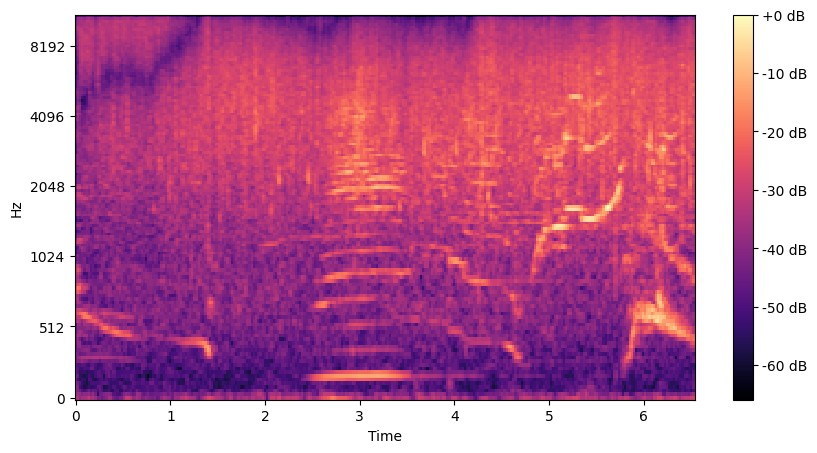

In [9]:
#Cleaning and Normalization

def clean_whale_audio(y, sr):
    
    #Filter
    y_filtered = librosa.effects.preemphasis(y)
    
    # 2. Trim 0Hz
    y_trimmed, index = librosa.effects.trim(y_filtered, top_db=20)
    
    #Normalization
    y_normalized = y_trimmed / np.max(np.abs(y_trimmed))
    
    return y_normalized

#10s clip
file_path = "assets/Whale_carrinbean_Sep2015.wav"
y_raw, sr = librosa.load(file_path, duration=10.0, sr=22050)

y_clean = clean_whale_audio(y_raw, sr)

#plot
spectrogram = librosa.feature.melspectrogram(y=y_clean, sr=sr)
spectrogram_db = librosa.power_to_db(spectrogram, ref=np.max)

plt.figure(figsize=(10, 5))
librosa.display.specshow(spectrogram_db, sr=sr, x_axis='time', y_axis='mel')

plt.colorbar(format='%+2.0f dB')
plt.show()

In [12]:
#Slicing 

chunk_duration = 3.0 # seconds
samples_per_chunk = int(chunk_duration * sr)


features_list = []

print(f"Audio Slice {chunk_duration}")

#for loop
for i in range(0, len(y_clean), samples_per_chunk): 

    chunk = y_clean[i : i + samples_per_chunk]    
    if len(chunk) < samples_per_chunk:
        continue

    #feature extraction mfcc
    mfccs = librosa.feature.mfcc(y=chunk, sr=sr, n_mfcc=13)
    scaled_features = np.mean(mfccs.T, axis=0)
    features_list.append(scaled_features)

#np array
X = np.array(features_list)

print(f"Extracted Features {X.shape[0]}")
print(f"One chunk is {X.shape[1]}")


Audio Slice 3.0
Extracted Features 2
One chunk is 13
